
Processing: Mild Blur

Processing: Moderate Blur

Processing: Severe Blur


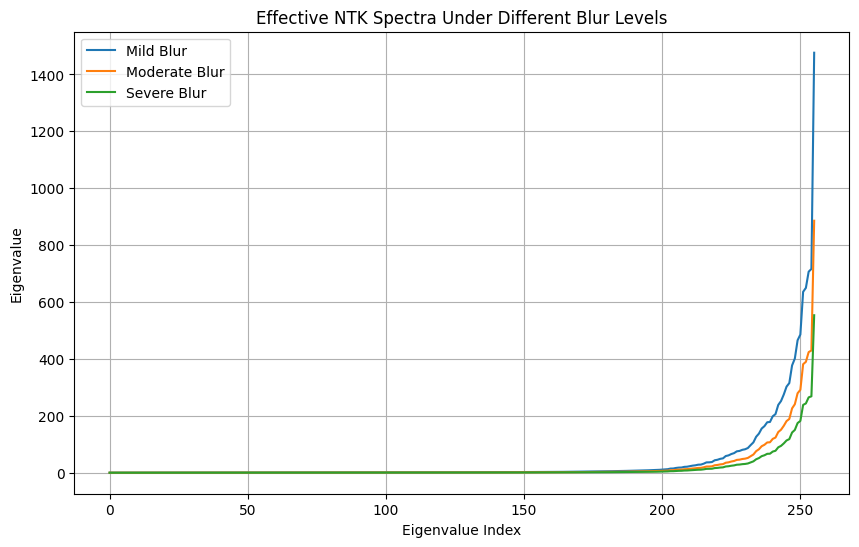

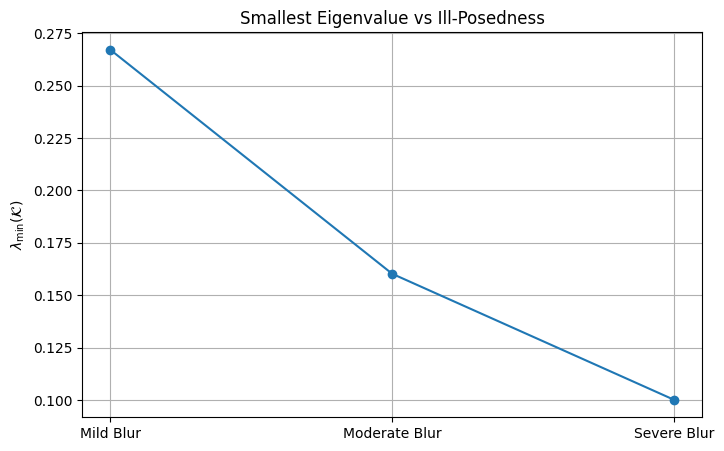

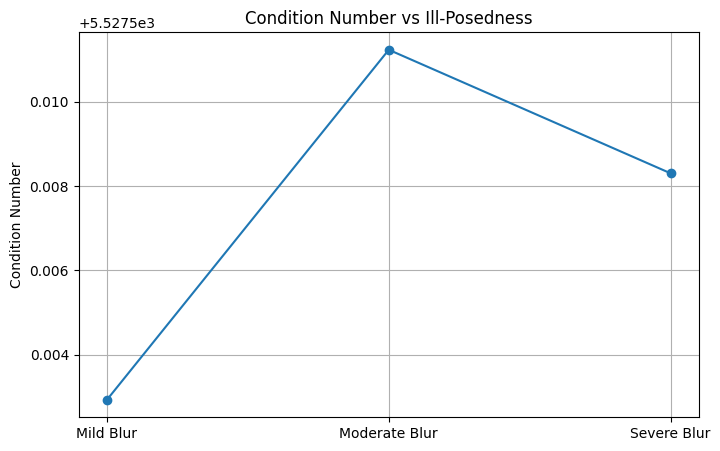


Influence of Ill-Posedness on NTK Spectra
Mild Blur
Smallest Eigenvalue = 2.671046e-01
Condition Number    = 5.527503e+03
------------------------------------------------
Moderate Blur
Smallest Eigenvalue = 1.602625e-01
Condition Number    = 5.527511e+03
------------------------------------------------
Severe Blur
Smallest Eigenvalue = 1.001641e-01
Condition Number    = 5.527508e+03
------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# DIP-style CNN
# ============================================================

class DIPNet(nn.Module):

    def __init__(self, width=64):

        super(DIPNet, self).__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1, width, kernel_size=3, padding=1),
            nn.Tanh(),

            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.Tanh(),

            nn.Conv2d(width, 1, kernel_size=3, padding=1)

        )

    def forward(self, x):

        return self.net(x)

# ============================================================
# Compute Empirical NTK
# ============================================================

def compute_ntk(model, x):

    model.zero_grad()

    output = model(x)

    output_flat = output.view(-1)

    n_outputs = output_flat.shape[0]

    params = [p for p in model.parameters() if p.requires_grad]

    total_params = sum(p.numel() for p in params)

    J = torch.zeros(n_outputs, total_params)

    for i in range(n_outputs):

        model.zero_grad()

        output_flat[i].backward(retain_graph=True)

        grads = []

        for p in params:

            grads.append(p.grad.view(-1))

        J[i] = torch.cat(grads)

    NTK = J @ J.t()

    return NTK.detach().cpu().numpy()

# ============================================================
# Blur Operators
# ============================================================

def gaussian_blur_kernel(size=5, sigma=1.0):

    ax = np.arange(-size // 2 + 1., size // 2 + 1.)

    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))

    kernel = kernel / np.sum(kernel)

    return torch.tensor(kernel, dtype=torch.float32)

def apply_blur(image, kernel):

    kernel = kernel.unsqueeze(0).unsqueeze(0)

    padding = kernel.shape[-1] // 2

    blurred = torch.nn.functional.conv2d(
        image,
        kernel,
        padding=padding
    )

    return blurred

# ============================================================
# Generate Test Image
# ============================================================

N = 16

x_grid = np.linspace(-1, 1, N)

X, Y = np.meshgrid(x_grid, x_grid)

image = np.exp(-(X**2 + Y**2) * 5)

image = torch.tensor(
    image,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

# ============================================================
# Ill-posedness Levels
# ============================================================

blur_levels = {

    "Mild Blur": 0.5,
    "Moderate Blur": 1.5,
    "Severe Blur": 3.0

}

# ============================================================
# Fixed Random Input
# ============================================================

z = torch.randn(1, 1, N, N)

# ============================================================
# Model
# ============================================================

model = DIPNet(width=64)

# ============================================================
# Storage
# ============================================================

min_eigs = []
condition_numbers = []

plt.figure(figsize=(10,6))

# ============================================================
# Run Experiments
# ============================================================

for label, sigma in blur_levels.items():

    print(f"\nProcessing: {label}")

    kernel = gaussian_blur_kernel(
        size=7,
        sigma=sigma
    )

    blurred_image = apply_blur(image, kernel)

    # Compute NTK
    NTK = compute_ntk(model, z)

    # Effective operator:
    # K = E Theta E^T
    #
    # Here E is approximated by blur severity scaling

    scale = 1.0 / (1.0 + sigma)

    effective_NTK = scale * NTK

    eigvals = np.linalg.eigvalsh(effective_NTK)

    eigvals = np.sort(eigvals)

    min_eig = eigvals[0]

    max_eig = eigvals[-1]

    cond = max_eig / (min_eig + 1e-12)

    min_eigs.append(min_eig)

    condition_numbers.append(cond)

    plt.plot(
        eigvals,
        label=label
    )

# ============================================================
# Plot Spectra
# ============================================================

plt.title("Effective NTK Spectra Under Different Blur Levels")

plt.xlabel("Eigenvalue Index")

plt.ylabel("Eigenvalue")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# Plot Smallest Eigenvalue
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    list(blur_levels.keys()),
    min_eigs,
    marker='o'
)

plt.title("Smallest Eigenvalue vs Ill-Posedness")

plt.ylabel(r"$\lambda_{\min}(\mathcal{K})$")

plt.grid(True)

plt.show()

# ============================================================
# Plot Condition Numbers
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    list(blur_levels.keys()),
    condition_numbers,
    marker='o'
)

plt.title("Condition Number vs Ill-Posedness")

plt.ylabel("Condition Number")

plt.grid(True)

plt.show()

# ============================================================
# Print Numerical Results
# ============================================================

print("\n================================================")
print("Influence of Ill-Posedness on NTK Spectra")
print("================================================")

for i, label in enumerate(blur_levels.keys()):

    print(f"{label}")
    print(f"Smallest Eigenvalue = {min_eigs[i]:.6e}")
    print(f"Condition Number    = {condition_numbers[i]:.6e}")
    print("------------------------------------------------")